# Задание № 2 (3 балла):
1. Загрузить последовательность отсчетов из файла «var\$\$_z2.bin», где \$\$ - номер варианта.
Формат записи данных в файле — бинарный, $double$ (8 байт на отсчет); частота
дискретизации 1 кГц.
2. Посчитать БПФ-спектр последовательности отсчетов, предварительно умножив
последовательность на окно (см. таблицу ниже). Длина (количество элементов) спектра
должно совпадать с числом отсчетов исходного ряда.
3. Изобразить полученный спектр на графике частота [Гц] — амплитуда в логарифмическом
масштабе.
4. Определить частоты гармоник, содержащиеся в сигнале, а также уровень шумов.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
data = np.fromfile("./data/lab_3_z2.bin", dtype=np.float64)
time = np.arange(len(data)) / 1000

len(data)

1000

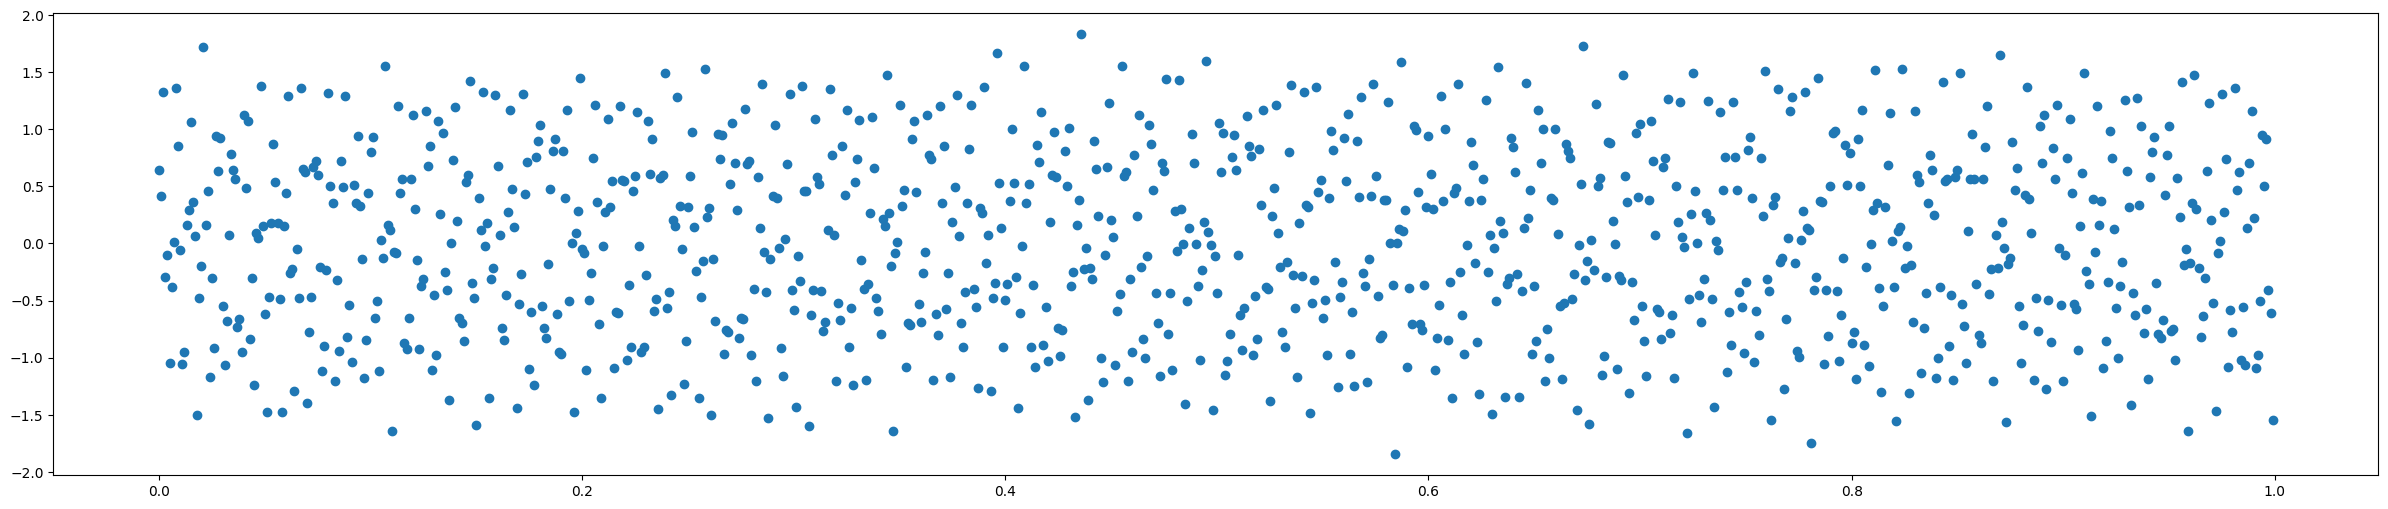

In [34]:
plt.figure(figsize=(30, 6))
plt.scatter(time, data)

In [35]:
def NattallWindow(n, N):
    a_0 = 0.3635819
    a_1 = 0.4891775
    a_2 = 0.1365995
    a_3 = 0.0106411
    
    cos_1 = np.cos(2 * np.pi * n / (N - 1))
    cos_2 = np.cos(4 * np.pi * n / (N - 1))
    cos_3 = np.cos(6 * np.pi * n / (N - 1))
    
    return a_0 - a_1 * cos_1 + a_2 * cos_2 - a_3 * cos_3

In [36]:
nat_data = [NattallWindow(i, len(data)) * data[i] for i in range(0, len(data))]

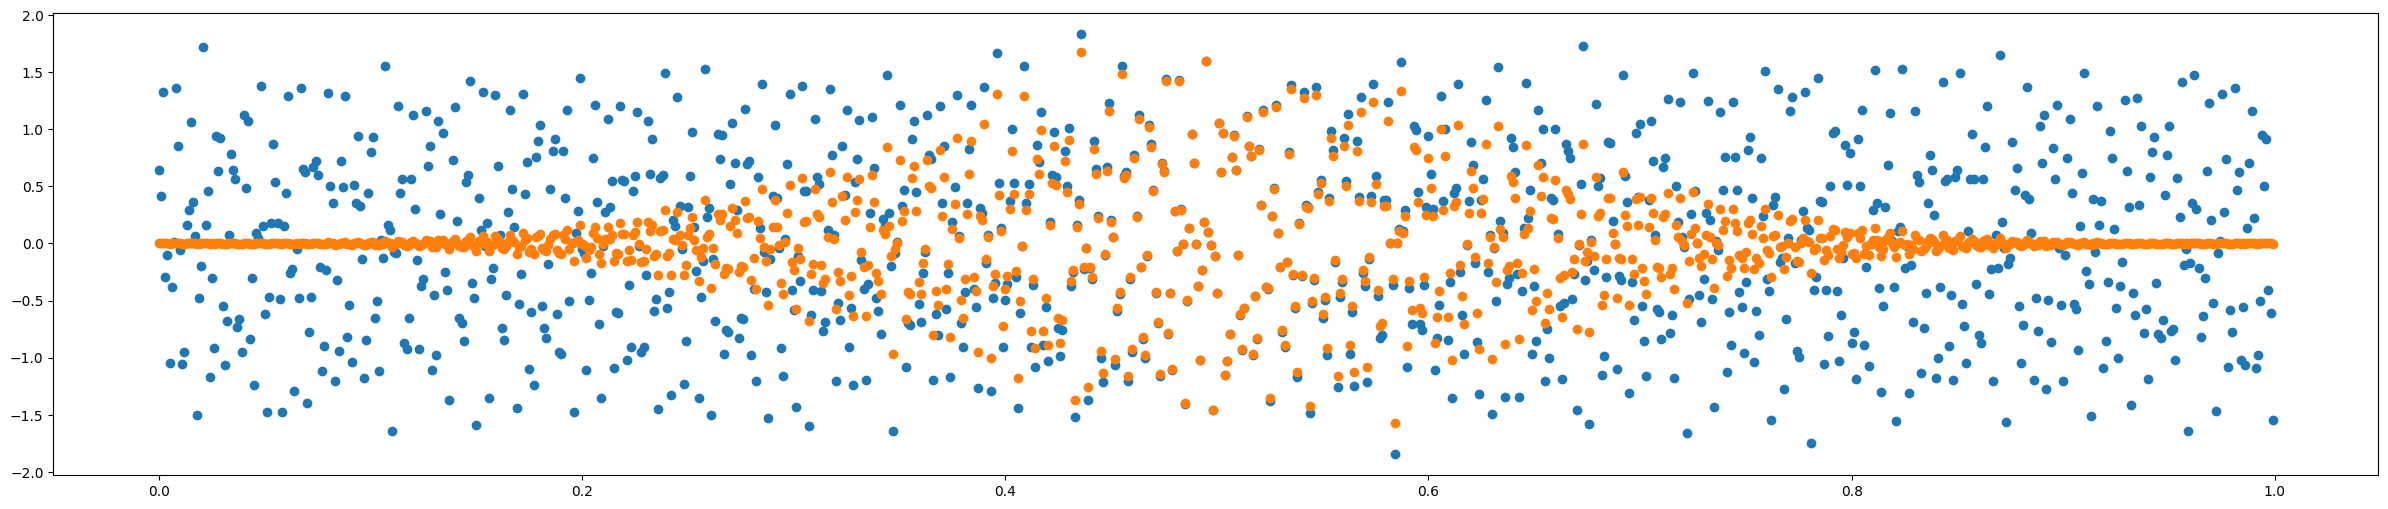

In [37]:
plt.figure(figsize=(30, 6))

plt.scatter(time, data)
plt.scatter(time, nat_data)

In [38]:
def FastFurieTransform(data):
    coef = 2 * np.pi / len(data)
    fft_data = []
    for k in range(len(data)):
        re_el = 0
        im_el = 0
        for n in range(len(data)):
            re_el += data[n] * np.cos(coef * k * n)
            im_el += -data[n] * np.sin(coef * k * n)
        fft_data.append((re_el, im_el))
        
    return fft_data

In [39]:
fft_data = FastFurieTransform(nat_data)
fft_data

[(np.float64(2.7833079622189065), np.float64(0.0)),
 (np.float64(-2.4957742841859614), np.float64(0.05886009978128952)),
 (np.float64(1.6282990361639191), np.float64(0.01657993816293594)),
 (np.float64(-0.4297550696457244), np.float64(-0.22445357489817613)),
 (np.float64(-0.5202063650252191), np.float64(0.04117236164419929)),
 (np.float64(0.7283059008150216), np.float64(0.9400572178266355)),
 (np.float64(-0.3099956975582787), np.float64(-1.30888180249099)),
 (np.float64(-0.5767568619470252), np.float64(0.04193335242529338)),
 (np.float64(1.1039287384671912), np.float64(1.5895357783732746)),
 (np.float64(-0.5126311938147409), np.float64(-1.9692167105494904)),
 (np.float64(-0.08089118381484986), np.float64(0.9951081835584721)),
 (np.float64(0.11099866785064508), np.float64(0.07529975687353734)),
 (np.float64(0.22093441565653893), np.float64(-0.4029907811380176)),
 (np.float64(-0.7300044053347797), np.float64(0.10987052988702614)),
 (np.float64(0.6197226309165619), np.float64(0.2397510642

In [40]:
N = len(fft_data)
fft_magnitude = [np.abs(fft_data[i][0]**2 + fft_data[i][1]**2) for i in range(len(fft_data[:N//2]))]

f = [1000 * i / N for i in range(N // 2)]
A = [20 * np.log10(el + 1e-12) for el in fft_magnitude]

In [60]:
noise = A[:150] + A[155:251] + A[256:475] + A[480:]
f_n = f[:150] + f[155:251] + f[256:475] + f[480:]

noise_A = np.average(noise)
noise_A

np.float64(3.2686019298003255)

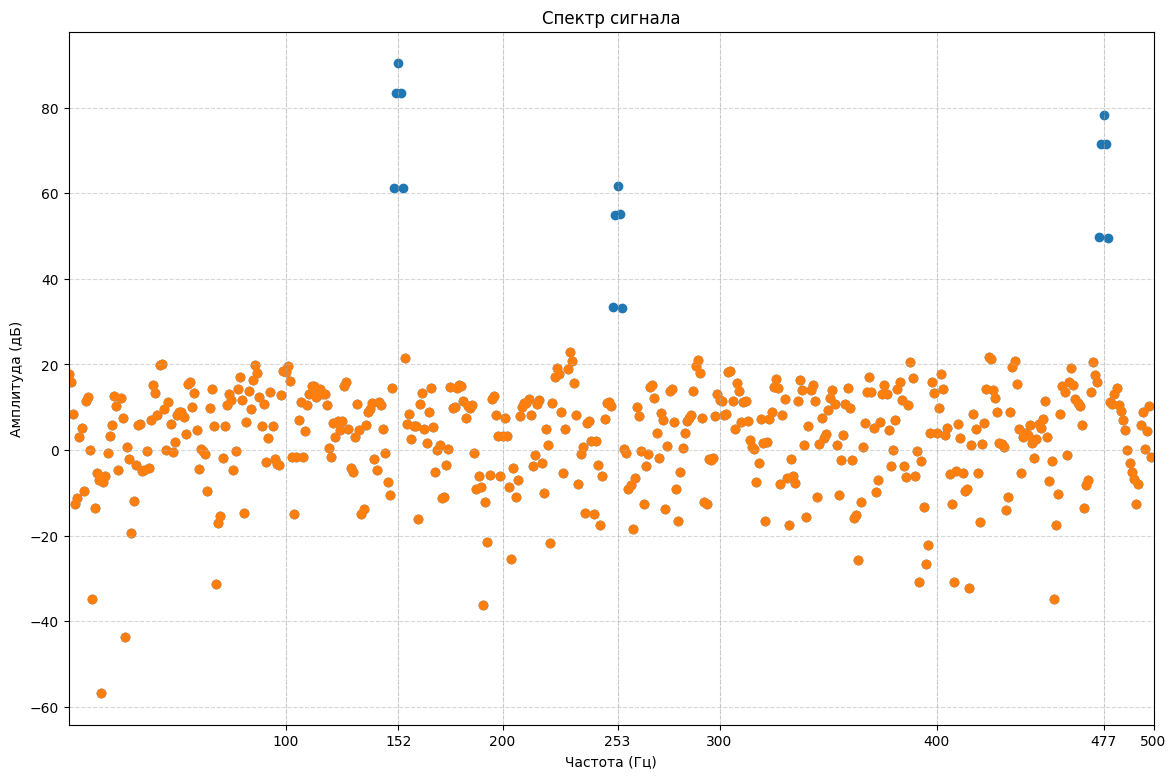

In [59]:
# Построение графика
fig, ax = plt.subplots(figsize=(14, 9))
plt.scatter(f, A) #если нужен линейный X
plt.scatter(f_n, noise) #если нужен линейный X
# Часто используют линейную шкалу по X, но логарифмическую по Y.
# Уточните у преподавателя: "частота [Гц] — амплитуда в логарифмическом масштабе" 
# обычно означает semilogy (ось Y логарифмическая), но часто делают и log-log.
# Правильнее всего: plt.plot(freqs, magnitude_db); 
# Тогда X - линейный, Y - в дБ (логарифмическая мера).

plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.title('Спектр сигнала')
plt.grid(True, which='both', linestyle='--', alpha=0.5)


data_x = [100, 152, 200, 253, 300, 400, 477, 500]
for x in data_x:
    ax.axvline(x=x, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
    
plt.xticks(ticks=data_x, labels=data_x)

plt.xlim(0, 1000/2)  # Ограничиваем частотой Найквиста (500 Гц)
plt.show()